# Notebook 07 — Statistical Testing and Confidence Interval Analysis

> **Scope** This notebook performs **statistical validation** of the model comparison results from Notebook 06.  
> It uses **only fold-level cross-validation scores** from `statistical_testing_input.csv`.  
> It does **not** perform model retraining, optimization, or test-set statistical testing.

| Reviewer concern | Addressed by |
|---|---|
| E.03 — statistical reliability, variability | Bootstrap CIs (2), summary table (4) |
| R5.05 — rigorous significance testing | Wilcoxon signed-rank test (2) |
| R6.10 — significance testing | Per-model corrected p-values (3) |
| R6.12 — confidence intervals | 95 % bootstrap CI for every comparison (2) |
| R3.02 — robustness of high-performance claims | Effect sizes + CI excluding zero (2–4) |

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import wilcoxon as sp_wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

from utils.plot_config import (
    apply_plot_style, clean_ax,
    CB_BLUE, CB_ORANGE, CB_GREEN,
    IEEE_DOUBLE_COL,
)

# ── Reproducibility constants ──────────────────────────────────────────────────
RANDOM_SEED  = 42
N_BOOTSTRAP  = 5000       # bootstrap resamples for CI estimation
ALPHA        = 0.05       # significance threshold
SCORE_COL    = 'Accuracy' # fold-level metric column in input CSV

# ── Comparison definitions  (method_A, method_B, label) ───────────────────────
# Mean_Difference = score(method_B) − score(method_A)
# Positive value → method_B outperforms method_A
COMPARISONS = [
    ('Baseline', 'TPE', 'Baseline vs TPE'),
    ('Baseline', 'GWO', 'Baseline vs GWO'),
    ('TPE',      'GWO', 'TPE vs GWO'),
]

# ── Colour map per comparison (colour-blind-safe) ──────────────────────────────
COMP_COLORS = {
    'Baseline vs TPE': CB_BLUE,
    'Baseline vs GWO': CB_ORANGE,
    'TPE vs GWO'     : CB_GREEN,
}

# ── Output paths ───────────────────────────────────────────────────────────────
TABLES_DIR  = Path('../results/tables')
FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

apply_plot_style()
print("Configuration loaded.")
print(f"  Bootstrap resamples : {N_BOOTSTRAP}")
print(f"  Random seed         : {RANDOM_SEED}")
print(f"  Significance alpha  : {ALPHA}")
print(f"  Score column        : {SCORE_COL}")
print(f"  Tables → {TABLES_DIR.resolve()}")
print(f"  Figures → {FIGURES_DIR.resolve()}")

Configuration loaded.
  Bootstrap resamples : 5000
  Random seed         : 42
  Significance alpha  : 0.05
  Score column        : Accuracy
  Tables → C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables
  Figures → C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures


---
## 1 · Load and Validate Input Data

Load `statistical_testing_input.csv` and enforce:

- Required columns: `Model`, `Method`, `Fold`, `Accuracy`
- Exactly 3 methods: `Baseline`, `TPE`, `GWO`
- Exactly 5 folds per `(Model, Method)` pair
- No missing values; `Accuracy` is numeric
- Fold identifiers are **identical across methods** for every model (pairing check)

In [2]:
# ── Load ───────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(TABLES_DIR / 'statistical_testing_input.csv')
print(f"Loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} cols")
display(df_raw.head(12))

# ── Schema checks ──────────────────────────────────────────────────────────────
required_cols = {'Model', 'Method', 'Fold', SCORE_COL}
missing_cols  = required_cols - set(df_raw.columns)
assert not missing_cols, f"Missing columns: {missing_cols}"

assert pd.api.types.is_numeric_dtype(df_raw[SCORE_COL]), \
    f"Score column '{SCORE_COL}' must be numeric; got {df_raw[SCORE_COL].dtype}"

assert df_raw[SCORE_COL].isna().sum() == 0, \
    "Missing values found in score column"

assert set(df_raw['Method'].unique()) == {'Baseline', 'TPE', 'GWO'}, \
    f"Unexpected methods: {sorted(df_raw['Method'].unique())}"

fold_counts = df_raw.groupby(['Model', 'Method'])['Fold'].nunique()
bad_counts  = fold_counts[fold_counts != 5]
assert bad_counts.empty, \
    f"Expected exactly 5 folds per (Model, Method):\n{bad_counts}"

# ── Pairing check: fold IDs must be identical across methods per model ─────────
for model, grp in df_raw.groupby('Model'):
    folds_per_method = grp.groupby('Method')['Fold'].apply(set)
    ref_folds = folds_per_method.iloc[0]
    for method, folds in folds_per_method.items():
        assert folds == ref_folds, \
            f"Fold mismatch for model '{model}', method '{method}'"

MODELS = sorted(df_raw['Model'].unique())
print(f"\nAll validation checks passed ✓")
print(f"  Models  ({len(MODELS)}): {MODELS}")
print(f"  Methods (3)  : {sorted(df_raw['Method'].unique())}")
print(f"  Folds per (Model, Method): 5")

Loaded: 210 rows × 4 cols


,Model,Method,Fold,Accuracy
0,AdaBoost,Baseline,1,0.890312
1,AdaBoost,Baseline,2,0.896042
2,AdaBoost,Baseline,3,0.874687
3,AdaBoost,Baseline,4,0.889167
4,AdaBoost,Baseline,5,0.887604
5,AdaBoost,TPE,1,0.951146
6,AdaBoost,TPE,2,0.950313
7,AdaBoost,TPE,3,0.949479
8,AdaBoost,TPE,4,0.949792
9,AdaBoost,TPE,5,0.950729



All validation checks passed ✓
  Models  (14): ['AdaBoost', 'CB', 'GB', 'KNN', 'LDA', 'LGBM', 'LR', 'LinearSVC', 'NB', 'QDA', 'RF', 'SGD', 'SVM', 'XGB']
  Methods (3)  : ['Baseline', 'GWO', 'TPE']
  Folds per (Model, Method): 5


---
## 2 · Pairwise Statistical Tests

For each model × comparison triple:

1. **Wilcoxon signed-rank test** (two-sided, paired) — appropriate for *n* = 5; no normality assumption.
2. **95 % bootstrap CI** of the mean paired difference — 5 000 resamples, paired fold-differences, fixed seed.
3. **Rank-biserial correlation** (*r*) — signed effect size derived from the differences array.

**Direction convention** — `Mean_Difference = score(method_B) − score(method_A)`.  
A positive value means method_B outperforms method_A on average across folds.

### Effect Size Interpretation

| r| range | Interpretation |
|---|---|---|
|1 | < 0.10 | Negligible |
|2 | 0.10 – 0.29 | Small |
|3 | 0.30 – 0.49 | Medium |
|4 | ≥ 0.50 | Large |


> These thresholds follow the conventional rank-biserial effect-size guidelines  
> (Cohen, 1988; Kerby, 2014).

In [3]:
# ── Helper: rank-biserial correlation from paired differences ──────────────────
def rank_biserial(differences):
    """
    Signed rank-biserial correlation r = (T+ - T-) / (n*(n+1)/2).

    Parameters
    ----------
    differences : array-like
        Paired differences (B - A).  Positive → B outperforms A.

    Returns
    -------
    float in [-1, 1].  Positive → B systematically higher; negative → A higher.
    """
    d    = np.asarray(differences, dtype=float)
    d_nz = d[d != 0]
    n    = len(d_nz)
    if n == 0:
        return 0.0
    ranks = rankdata(np.abs(d_nz))
    t_pos = float(ranks[d_nz > 0].sum())
    t_neg = float(ranks[d_nz < 0].sum())
    return (t_pos - t_neg) / (n * (n + 1) / 2)


def effect_size_label(r):
    """Map |rank-biserial r| to qualitative label."""
    a = abs(r)
    if a < 0.10: return 'Negligible'
    if a < 0.30: return 'Small'
    if a < 0.50: return 'Medium'
    return 'Large'


# ── Helper: paired bootstrap 95 % CI ──────────────────────────────────────────
def bootstrap_ci(differences, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    """
    95 % percentile bootstrap CI for the mean of paired fold-differences.

    Resamples the difference array with replacement.
    """
    rng  = np.random.default_rng(seed)
    d    = np.asarray(differences, dtype=float)
    boot = np.array([
        rng.choice(d, size=len(d), replace=True).mean()
        for _ in range(n_boot)
    ])
    return float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))


# ── Main statistical computation loop ─────────────────────────────────────────
rows = []

for model in MODELS:
    mdf = df_raw[df_raw['Model'] == model]

    for method_a, method_b, comp_label in COMPARISONS:
        scores_a = (mdf[mdf['Method'] == method_a]
                    .sort_values('Fold')[SCORE_COL].values)
        scores_b = (mdf[mdf['Method'] == method_b]
                    .sort_values('Fold')[SCORE_COL].values)

        assert len(scores_a) == 5 and len(scores_b) == 5, \
            f"Unexpected fold count for {model} / {comp_label}"

        d         = scores_b - scores_a        # B − A (positive → B better)
        mean_diff = float(d.mean())

        # ── Wilcoxon signed-rank test (two-sided) ─────────────────────────────
        try:
            w_stat, p_raw = sp_wilcoxon(
                d, alternative='two-sided', zero_method='wilcox'
            )
        except ValueError:
            # All differences are exactly zero (degenerate case)
            w_stat, p_raw = 0.0, 1.0

        # ── 95 % bootstrap CI ─────────────────────────────────────────────────
        ci_lo, ci_hi = bootstrap_ci(d)

        # ── Rank-biserial effect size ──────────────────────────────────────────
        r     = rank_biserial(d)
        label = effect_size_label(r)

        rows.append({
            'Model'              : model,
            'Comparison'         : comp_label,
            'Mean_Difference'    : mean_diff,
            'CI_Lower'           : ci_lo,
            'CI_Upper'           : ci_hi,
            'Wilcoxon_Statistic' : w_stat,
            'p_value'            : p_raw,
            'Effect_Size'        : r,
            'Effect_Size_Label'  : label,
        })

df_stats = pd.DataFrame(rows)
print(f"Statistics computed: {len(df_stats)} rows  ({len(MODELS)} models × 3 comparisons)")
display(df_stats.round(6))

Statistics computed: 42 rows  (14 models × 3 comparisons)


,Model,Comparison,Mean_Difference,CI_Lower,CI_Upper,Wilcoxon_Statistic,p_value,Effect_Size,Effect_Size_Label
0,AdaBoost,Baseline vs TPE,0.062729,0.057354,0.069208,0.0,0.0625,1.000000,Large
1,AdaBoost,Baseline vs GWO,0.064437,0.059042,0.071375,0.0,0.0625,1.000000,Large
2,AdaBoost,TPE vs GWO,0.001708,0.001146,0.002312,0.0,0.0625,1.000000,Large
3,CB,Baseline vs TPE,0.006646,0.005688,0.007792,0.0,0.0625,1.000000,Large
4,CB,Baseline vs GWO,0.007000,0.006042,0.007792,0.0,0.0625,1.000000,Large
5,CB,TPE vs GWO,0.000354,-0.000146,0.000979,4.0,0.4375,0.466667,Medium
6,GB,Baseline vs TPE,0.073229,0.069583,0.076750,0.0,0.0625,1.000000,Large
7,GB,Baseline vs GWO,0.073958,0.070417,0.077500,0.0,0.0625,1.000000,Large
8,GB,TPE vs GWO,0.000729,0.000458,0.000979,0.0,0.0625,1.000000,Large
9,KNN,Baseline vs TPE,0.015542,0.013854,0.017229,0.0,0.0625,1.000000,Large


---
## 3 · Multiple-Comparison Correction (Holm–Bonferroni)

Correction is applied **within each comparison family** (14 model-level tests per family):

| Family | Tests |
|---|---|
| Baseline vs TPE | 14 |
| Baseline vs GWO | 14 |
| TPE vs GWO | 14 |

> ⚠️ **Statistical-power note** — The Wilcoxon signed-rank test with *n* = 5 paired
> observations has a minimum attainable two-sided p-value of 2/32 = **0.0625**
> (achieved only when all 5 differences share the same sign; Conover, 1971).
> Consequently, **no individual Wilcoxon test can reach α = 0.05**, and Holm
> correction raises p-values further. This is a fundamental constraint of 5-fold CV,
> not a flaw in the analysis.
>
> **Confidence intervals** (§2) are therefore the **primary evidence** for performance
> differences and uncertainty quantification. Corrected p-values are reported for
> transparency and reviewer completeness.

The `CI_Excludes_Zero` flag (CI fully above or fully below zero) provides a conservative,
assumption-light indicator of practically meaningful differences without requiring a
significance threshold.

In [5]:
# ── Apply Holm–Bonferroni within each comparison family ───────────────────────
corrected_blocks = []

for comp_label in [c[2] for c in COMPARISONS]:
    subset = df_stats[df_stats['Comparison'] == comp_label].copy()
    reject, p_corr, _, _ = multipletests(
        subset['p_value'].values, alpha=ALPHA, method='holm'
    )
    subset['Corrected_p_value'] = p_corr
    subset['Significant']       = np.where(reject, 'Yes', 'No')
    corrected_blocks.append(subset)

df_stats = pd.concat(corrected_blocks, ignore_index=True)

# ── Convenience flag: CI excludes zero ────────────────────────────────────────
df_stats['CI_Excludes_Zero'] = (
    (df_stats['CI_Lower'] > 0) | (df_stats['CI_Upper'] < 0)
)

# ── Canonical column order ─────────────────────────────────────────────────────
col_order = [
    'Model', 'Comparison',
    'Mean_Difference', 'CI_Lower', 'CI_Upper',
    'Wilcoxon_Statistic', 'p_value', 'Corrected_p_value',
    'Effect_Size', 'Effect_Size_Label', 'Significant', 'CI_Excludes_Zero',
]
df_stats = df_stats[col_order]

# ── Sanity: corrected p ≥ raw p ───────────────────────────────────────────────
assert (df_stats['Corrected_p_value'] >= df_stats['p_value'] - 1e-12).all(), \
    "Corrected p-values should be ≥ raw p-values"

# ── Summary (primary evidence: CI; secondary: corrected p) ────────────────────
print("─" * 65)
print(f"{'Comparison':<20} {'N_Sig(Holm)':<14} {'N_CI_Excl_Zero':<17} {'Min_corr_p'}")
print("─" * 65)
for comp_label in [c[2] for c in COMPARISONS]:
    s     = df_stats[df_stats['Comparison'] == comp_label]
    n_sig = (s['Significant'] == 'Yes').sum()
    n_ci  = s['CI_Excludes_Zero'].sum()
    min_p = s['Corrected_p_value'].min()
    print(f"{comp_label:<20} {n_sig:<14} {n_ci:<17} {min_p:.4f}")
print("─" * 65)
print()
print("Note: With n=5 folds, min attainable Wilcoxon two-sided p = 0.0625.")
print("      CI_Excludes_Zero is the primary practical significance indicator.")
print()
display(df_stats.round(6))

─────────────────────────────────────────────────────────────────
Comparison           N_Sig(Holm)    N_CI_Excl_Zero    Min_corr_p
─────────────────────────────────────────────────────────────────
Baseline vs TPE      0              10                0.8750
Baseline vs GWO      0              11                0.8750
TPE vs GWO           0              4                 0.8750
─────────────────────────────────────────────────────────────────

Note: With n=5 folds, min attainable Wilcoxon two-sided p = 0.0625.
      CI_Excludes_Zero is the primary practical significance indicator.



,Model,Comparison,Mean_Difference,CI_Lower,CI_Upper,Wilcoxon_Statistic,p_value,Corrected_p_value,Effect_Size,Effect_Size_Label,Significant,CI_Excludes_Zero
0,AdaBoost,Baseline vs TPE,0.062729,0.057354,0.069208,0.0,0.0625,0.875,1.000000,Large,No,True
1,CB,Baseline vs TPE,0.006646,0.005688,0.007792,0.0,0.0625,0.875,1.000000,Large,No,True
2,GB,Baseline vs TPE,0.073229,0.069583,0.076750,0.0,0.0625,0.875,1.000000,Large,No,True
3,KNN,Baseline vs TPE,0.015542,0.013854,0.017229,0.0,0.0625,0.875,1.000000,Large,No,True
4,LDA,Baseline vs TPE,0.000000,0.000000,0.000000,0.0,1.0000,1.000,0.000000,Negligible,No,False
5,LGBM,Baseline vs TPE,0.030167,0.028812,0.031729,0.0,0.0625,0.875,1.000000,Large,No,True
6,LR,Baseline vs TPE,0.002208,0.000917,0.003625,0.0,0.1250,0.875,1.000000,Large,No,True
7,LinearSVC,Baseline vs TPE,0.000063,-0.000083,0.000208,3.0,0.6250,1.000,0.400000,Medium,No,False
8,NB,Baseline vs TPE,0.000000,0.000000,0.000000,0.0,1.0000,1.000,0.000000,Negligible,No,False
9,QDA,Baseline vs TPE,0.006542,0.004104,0.008792,0.0,0.0625,0.875,1.000000,Large,No,True


---
## 4 · Export Manuscript Tables

| File | Description |
|---|---|
| `statistical_test_results.csv` | Full 42-row inferential table (per model × comparison) |
| `statistical_summary.csv` | Aggregated significance/effect summary per comparison family |
| `statistical_manuscript_notes.csv` | Concise writing-support statements for the manuscript |

In [6]:
# ─── Table 1: statistical_test_results.csv ────────────────────────────────────
out_1 = TABLES_DIR / 'statistical_test_results.csv'
df_stats.to_csv(out_1, index=False)
print(f"Saved ({len(df_stats)} rows): {out_1.name}")

# ─── Table 2: statistical_summary.csv ─────────────────────────────────────────
summary_rows = []
for comp_label in [c[2] for c in COMPARISONS]:
    s       = df_stats[df_stats['Comparison'] == comp_label]
    n_total = len(s)
    n_sig   = int((s['Significant'] == 'Yes').sum())
    n_ci_nz = int(s['CI_Excludes_Zero'].sum())
    summary_rows.append({
        'Comparison'          : comp_label,
        'N_Models'            : n_total,
        'N_Significant_Holm'  : n_sig,
        'Pct_Significant_Holm': round(n_sig / n_total * 100, 1),
        'N_CI_Excludes_Zero'  : n_ci_nz,
        'Pct_CI_Excludes_Zero': round(n_ci_nz / n_total * 100, 1),
        'Mean_Effect_Size'    : round(float(s['Effect_Size'].mean()),   4),
        'Median_Effect_Size'  : round(float(s['Effect_Size'].median()), 4),
        'Mean_Difference_Avg' : round(float(s['Mean_Difference'].mean()), 6),
        'Min_Corrected_p'     : round(float(s['Corrected_p_value'].min()), 4),
    })

df_summary = pd.DataFrame(summary_rows)
out_2 = TABLES_DIR / 'statistical_summary.csv'
df_summary.to_csv(out_2, index=False)
print(f"Saved ({len(df_summary)} rows): {out_2.name}")
display(df_summary)

# ─── Table 3: statistical_manuscript_notes.csv ────────────────────────────────
bvt = df_stats[df_stats['Comparison'] == 'Baseline vs TPE']
bvg = df_stats[df_stats['Comparison'] == 'Baseline vs GWO']
tvg = df_stats[df_stats['Comparison'] == 'TPE vs GWO']

# Primary evidence: CI excludes zero
_bvt_ci  = sorted(bvt[bvt['CI_Excludes_Zero']]['Model'].tolist())
_bvg_ci  = sorted(bvg[bvg['CI_Excludes_Zero']]['Model'].tolist())
_tvg_ci  = sorted(tvg[tvg['CI_Excludes_Zero']]['Model'].tolist())

# Strongest improvement by CI count
_ci_counts = {r['Comparison']: r['N_CI_Excludes_Zero'] for _, r in df_summary.iterrows()}
_strongest = max(_ci_counts, key=_ci_counts.get)

notes = [
    {
        'Key' : 'power_limitation',
        'Note': (
            'With n=5 folds, the Wilcoxon signed-rank test has a minimum two-sided '
            'p-value of 0.0625 (Conover, 1971); no test can reach alpha=0.05. '
            'CIs are the primary uncertainty evidence.'
        ),
    },
    {
        'Key' : 'strongest_improvement_by_CI',
        'Note': (
            f"'{_strongest}' shows the most consistent improvement: "
            f"{_ci_counts[_strongest]}/{len(MODELS)} models have CIs excluding zero."
        ),
    },
    {
        'Key' : 'baseline_vs_tpe_ci_models',
        'Note': (
            f"Models where Baseline vs TPE CI excludes zero ({len(_bvt_ci)}/"
            f"{len(MODELS)}): "
            + (', '.join(_bvt_ci) if _bvt_ci else 'none')
        ),
    },
    {
        'Key' : 'baseline_vs_gwo_ci_models',
        'Note': (
            f"Models where Baseline vs GWO CI excludes zero ({len(_bvg_ci)}/"
            f"{len(MODELS)}): "
            + (', '.join(_bvg_ci) if _bvg_ci else 'none')
        ),
    },
    {
        'Key' : 'tpe_vs_gwo_differences',
        'Note': (
            f"Models where TPE vs GWO CI excludes zero ({len(_tvg_ci)}/"
            f"{len(MODELS)}): "
            + (', '.join(_tvg_ci) if _tvg_ci else 'none')
            + ('. Differences between optimizers are largely marginal.'
               if len(_tvg_ci) <= 4
               else '. Notable differences between optimizers detected.')
        ),
    },
    {
        'Key' : 'effect_size_context',
        'Note': (
            'Mean rank-biserial effect sizes — '
            + '; '.join(
                f"{r['Comparison']}: {r['Mean_Effect_Size']:.3f}"
                f" ({r['Median_Effect_Size']:.3f} median)"
                for _, r in df_summary.iterrows()
            )
        ),
    },
]

df_notes = pd.DataFrame(notes)
out_3 = TABLES_DIR / 'statistical_manuscript_notes.csv'
df_notes.to_csv(out_3, index=False)
print(f"Saved ({len(df_notes)} rows): {out_3.name}")
display(df_notes)

Saved (42 rows): statistical_test_results.csv
Saved (3 rows): statistical_summary.csv


,Comparison,N_Models,N_Significant_Holm,Pct_Significant_Holm,N_CI_Excludes_Zero,Pct_CI_Excludes_Zero,Mean_Effect_Size,Median_Effect_Size,Mean_Difference_Avg,Min_Corrected_p
0,Baseline vs TPE,14,0,0.0,10,71.4,0.7000,1.0000,0.015731,0.875
1,Baseline vs GWO,14,0,0.0,11,78.6,0.6476,1.0000,0.015824,0.875
2,TPE vs GWO,14,0,0.0,4,28.6,0.1571,0.0667,0.000094,0.875


Saved (6 rows): statistical_manuscript_notes.csv


,Key,Note
0,power_limitation,"With n=5 folds, the Wilcoxon signed-rank test ..."
1,strongest_improvement_by_CI,'Baseline vs GWO' shows the most consistent im...
2,baseline_vs_tpe_ci_models,Models where Baseline vs TPE CI excludes zero ...
3,baseline_vs_gwo_ci_models,Models where Baseline vs GWO CI excludes zero ...
4,tpe_vs_gwo_differences,Models where TPE vs GWO CI excludes zero (4/14...
5,effect_size_context,Mean rank-biserial effect sizes — Baseline vs ...


---
## 5 · Publication-Ready Figures

| Figure | File | Description |
|---|---|---|
| A | `confidence_interval_forest_plot` | Forest plot: mean difference + 95 % CI per model |
| B | `effect_size_plot` | Rank-biserial effect sizes with threshold guides |
| C | `pvalue_summary_plot` | Holm-corrected *p*-values heatmap |

All figures saved as **300 DPI PNG** and **vector PDF**.

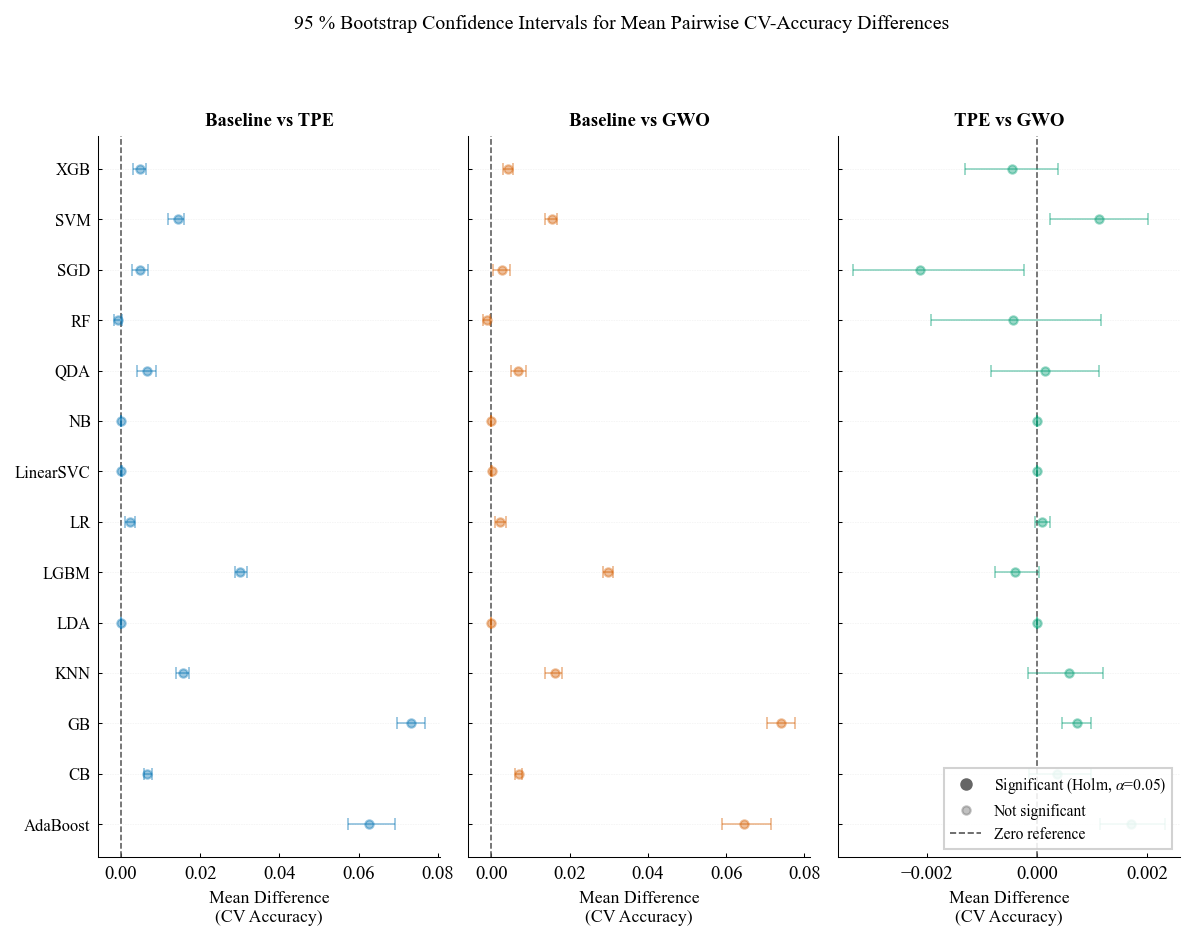

Figure A saved -> confidence_interval_forest_plot.png / .pdf


In [10]:
# ── Figure A: Confidence Interval Forest Plot ─────────────────────────────────
# Three panels (one per comparison), each showing mean difference + 95 % CI
# per model. Significant models are drawn at full opacity; a star (*) marks them.

apply_plot_style()

_comps       = [c[2] for c in COMPARISONS]
_model_order = sorted(MODELS)                   # alphabetical
_n_models    = len(_model_order)
_y_pos       = np.arange(_n_models)

fig, axes = plt.subplots(
    1, 3,
    figsize=(IEEE_DOUBLE_COL * 1.30, _n_models * 0.36 + 1.2),
    sharey=True,
)
fig.subplots_adjust(wspace=0.08)

for ax, (method_a, method_b, comp_label), color in zip(
        axes, COMPARISONS, [COMP_COLORS[c] for c in _comps]):

    sub  = (df_stats[df_stats['Comparison'] == comp_label]
            .set_index('Model').loc[_model_order])
    means  = sub['Mean_Difference'].values
    ci_lo  = sub['CI_Lower'].values
    ci_hi  = sub['CI_Upper'].values
    sigs   = sub['Significant'].values

    for i, (m, clo, chi, sig) in enumerate(
            zip(means, ci_lo, ci_hi, sigs)):
        alpha_val = 1.0 if sig == 'Yes' else 0.40
        ax.errorbar(
            m, _y_pos[i],
            xerr=[[m - clo], [chi - m]],
            fmt='o',
            color=color,
            ecolor=color,
            elinewidth=0.9,
            capsize=3,
            capthick=0.9,
            markersize=5 if sig == 'Yes' else 4,
            alpha=alpha_val,
            zorder=3,
        )
        if sig == 'Yes':
            x_star = max(chi, m) + abs(chi - clo) * 0.06
            ax.text(x_star, _y_pos[i], '*',
                    va='center', ha='left', fontsize=8, color=color,
                    fontweight='bold')

    ax.axvline(0, color='#555555', linewidth=0.75, linestyle='--', zorder=1)
    ax.set_yticks(_y_pos)
    ax.set_yticklabels(_model_order, fontsize=8)
    ax.set_xlabel('Mean Difference\n(CV Accuracy)', fontsize=8.5)
    ax.set_title(comp_label, fontsize=9, fontweight='bold', pad=5)
    clean_ax(ax)

# Shared legend (rightmost panel)
_leg_handles = [
    Line2D([0], [0], marker='o', color='#666666', markersize=5,
           linestyle='None', alpha=1.0,
           label='Significant (Holm, $\\alpha$=0.05)'),
    Line2D([0], [0], marker='o', color='#666666', markersize=4,
           linestyle='None', alpha=0.40, label='Not significant'),
    Line2D([0], [0], color='#555555', linewidth=0.8, linestyle='--',
           label='Zero reference'),
]
axes[-1].legend(handles=_leg_handles, fontsize=7.5, loc='lower right',
                framealpha=0.88, edgecolor='#cccccc', fancybox=False)

fig.suptitle(
    '95 % Bootstrap Confidence Intervals for Mean Pairwise CV-Accuracy Differences',
    fontsize=9.5, y=1.01,
)

for ext in ('png', 'pdf'):
    fig.savefig(
        FIGURES_DIR / f'confidence_interval_forest_plot.{ext}',
        dpi=300, bbox_inches='tight',
        format=ext if ext == 'pdf' else None,
    )
plt.show()
print("Figure A saved -> confidence_interval_forest_plot.png / .pdf")

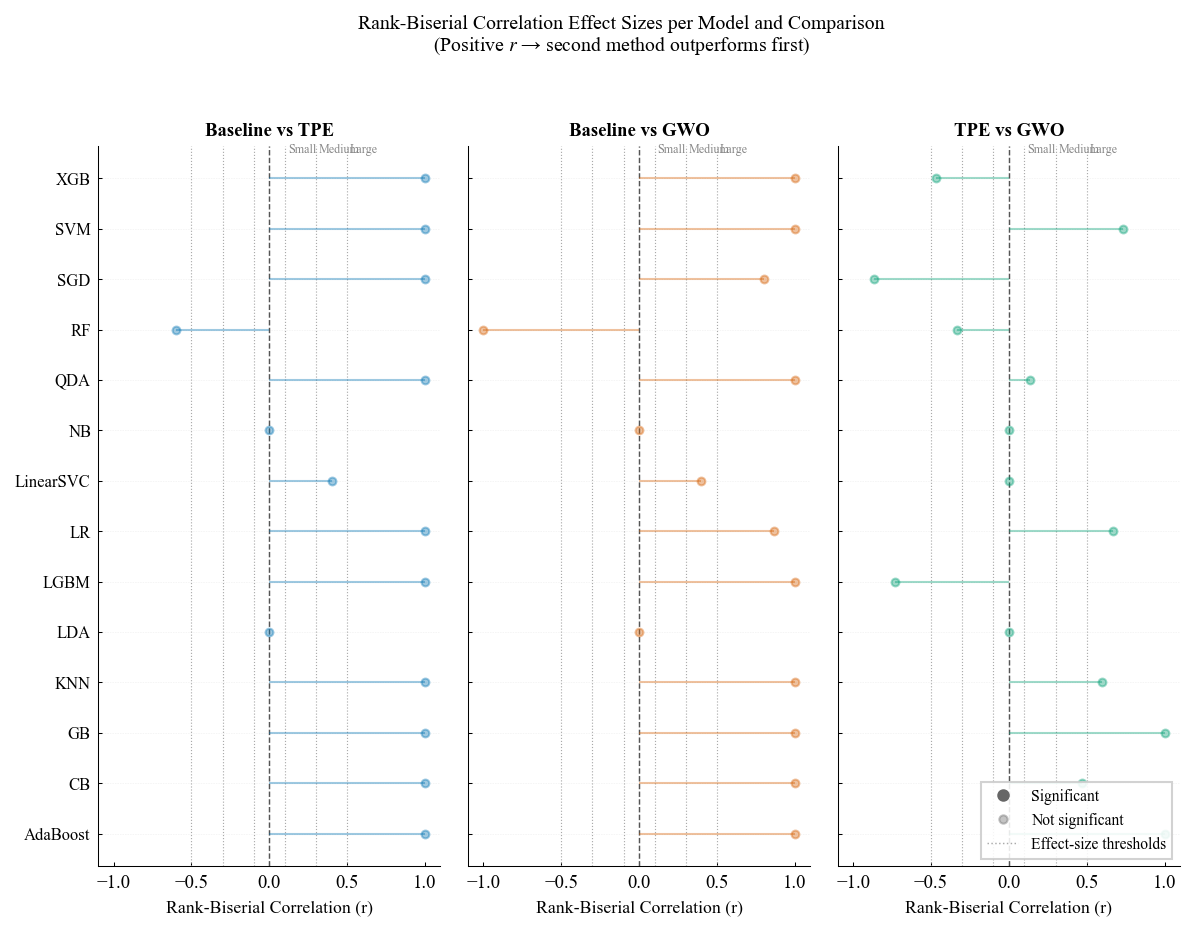

Figure B saved → effect_size_plot.png / .pdf


In [8]:
# ── Figure B: Effect Size Lollipop Plot ───────────────────────────────────────
# Three panels (one per comparison), each showing the rank-biserial r per model.
# Qualitative threshold guides (0.10, 0.30, 0.50) are drawn as dotted verticals.

apply_plot_style()

_comps       = [c[2] for c in COMPARISONS]
_model_order = sorted(MODELS)
_n_models    = len(_model_order)
_y_pos       = np.arange(_n_models)

THRESHOLDS = [
    (0.10, 'Small'),
    (0.30, 'Medium'),
    (0.50, 'Large'),
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(IEEE_DOUBLE_COL * 1.30, _n_models * 0.36 + 1.2),
    sharey=True,
)
fig.subplots_adjust(wspace=0.08)

for ax, (method_a, method_b, comp_label), color in zip(
        axes, COMPARISONS, [COMP_COLORS[c] for c in _comps]):

    sub  = (df_stats[df_stats['Comparison'] == comp_label]
            .set_index('Model').loc[_model_order])
    es   = sub['Effect_Size'].values
    sigs = sub['Significant'].values

    for i, (e, sig) in enumerate(zip(es, sigs)):
        alpha_val = 1.0 if sig == 'Yes' else 0.38
        # Stem from 0 to r
        ax.hlines(_y_pos[i], 0, e, color=color, linewidth=1.0,
                  alpha=alpha_val, zorder=2)
        ax.scatter(e, _y_pos[i], color=color,
                   s=22 if sig == 'Yes' else 14,
                   zorder=3, alpha=alpha_val)

    # Threshold guides
    for xval, tlabel in THRESHOLDS:
        ax.axvline(xval, color='#aaaaaa', linewidth=0.55, linestyle=':', zorder=1)
        ax.axvline(-xval, color='#aaaaaa', linewidth=0.55, linestyle=':', zorder=1)
        ax.text(xval + 0.02, _n_models - 0.3, tlabel,
                fontsize=5.8, color='#888888', va='top', ha='left')

    ax.axvline(0, color='#555555', linewidth=0.7, linestyle='--', zorder=1)
    ax.set_xlim(-1.10, 1.10)
    ax.set_yticks(_y_pos)
    ax.set_yticklabels(_model_order, fontsize=8)
    ax.set_xlabel('Rank-Biserial Correlation (r)', fontsize=8.5)
    ax.set_title(comp_label, fontsize=9, fontweight='bold', pad=5)
    clean_ax(ax)

_leg_handles = [
    Line2D([0], [0], marker='o', color='#666666', markersize=5,
           linestyle='None', alpha=1.0, label='Significant'),
    Line2D([0], [0], marker='o', color='#666666', markersize=4,
           linestyle='None', alpha=0.38, label='Not significant'),
    Line2D([0], [0], color='#aaaaaa', linewidth=0.7, linestyle=':',
           label='Effect-size thresholds'),
]
axes[-1].legend(handles=_leg_handles, fontsize=7.5, loc='lower right',
                framealpha=0.88, edgecolor='#cccccc', fancybox=False)

fig.suptitle(
    'Rank-Biserial Correlation Effect Sizes per Model and Comparison\n'
    r'(Positive $r$ → second method outperforms first)',
    fontsize=9.5, y=1.02,
)

for ext in ('png', 'pdf'):
    fig.savefig(
        FIGURES_DIR / f'effect_size_plot.{ext}',
        dpi=300, bbox_inches='tight',
        format=ext if ext == 'pdf' else None,
    )
plt.show()
print("Figure B saved → effect_size_plot.png / .pdf")

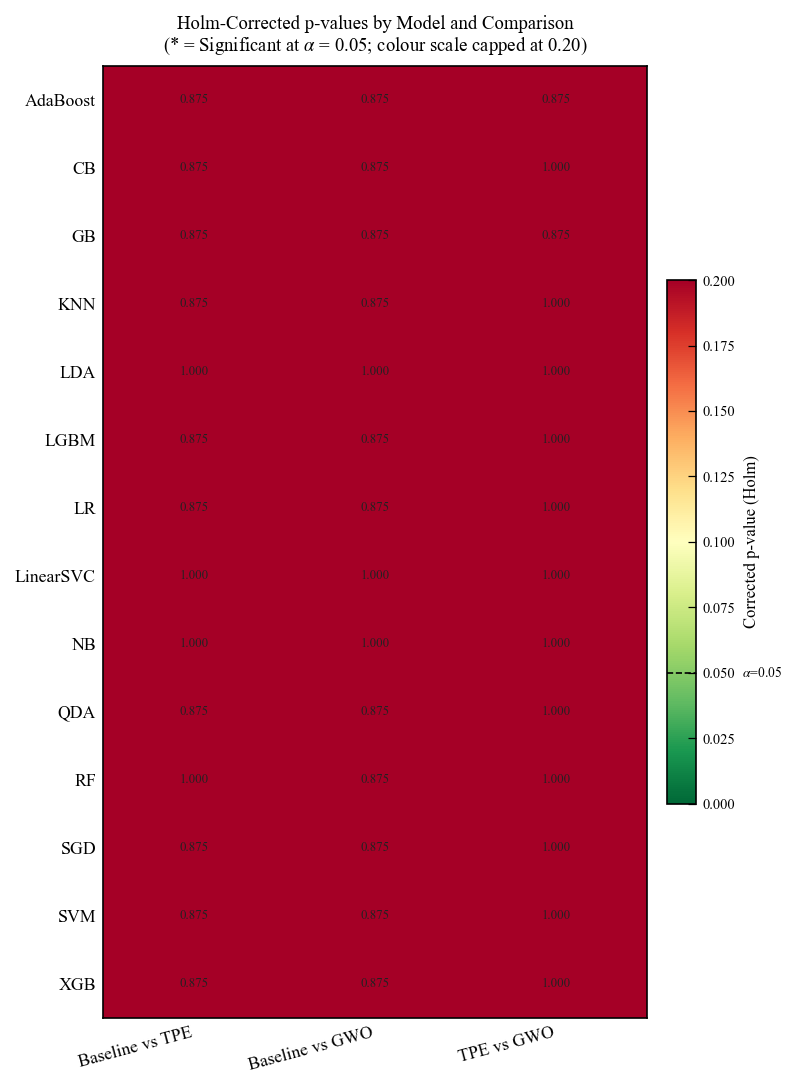

Figure C saved -> pvalue_summary_plot.png / .pdf


In [11]:
# ── Figure C: Holm-Corrected p-value Heatmap ─────────────────────────────────
# Shows corrected p-values for all 14 models x 3 comparisons.
# Note: with n=5 folds, min attainable Wilcoxon p = 0.0625; no cell reaches
# alpha=0.05. Values are saturated at 0.20 for colour contrast.

apply_plot_style()

_comps       = [c[2] for c in COMPARISONS]
_model_order = sorted(MODELS)
_n_models    = len(_model_order)

pv_pivot  = (df_stats
             .pivot(index='Model', columns='Comparison', values='Corrected_p_value')
             .loc[_model_order, _comps])
sig_pivot = (df_stats
             .pivot(index='Model', columns='Comparison', values='Significant')
             .loc[_model_order, _comps])

fig, ax = plt.subplots(figsize=(5.4, _n_models * 0.44 + 1.2))

im = ax.imshow(
    pv_pivot.values,
    aspect='auto',
    cmap='RdYlGn_r',
    vmin=0.0, vmax=0.20,
    interpolation='nearest',
)

cbar = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.03, aspect=18)
cbar.set_label('Corrected p-value (Holm)', fontsize=8)
cbar.ax.tick_params(labelsize=7)
cbar.ax.axhline(ALPHA, color='black', linewidth=0.8, linestyle='--')
cbar.ax.text(2.5, ALPHA, f' $\\alpha$={ALPHA}', va='center', fontsize=6.5,
             color='black', transform=cbar.ax.get_yaxis_transform())

# Cell annotations
for r_idx, model in enumerate(_model_order):
    for c_idx, comp in enumerate(_comps):
        pv  = pv_pivot.loc[model, comp]
        sig = sig_pivot.loc[model, comp]
        txt = f"{pv:.3f}" if pv >= 0.001 else "<0.001"
        text_color = 'white' if pv < 0.10 else '#222222'
        ax.text(c_idx, r_idx, txt,
                ha='center', va='center', fontsize=6.2, color=text_color)
        if sig == 'Yes':
            ax.text(c_idx + 0.40, r_idx - 0.28, '*',
                    ha='center', va='center', fontsize=8, color='white',
                    fontweight='bold')

ax.set_xticks(range(len(_comps)))
ax.set_xticklabels(_comps, fontsize=8.5, rotation=15, ha='right')
ax.set_yticks(range(_n_models))
ax.set_yticklabels(_model_order, fontsize=8.5)
ax.set_title(
    'Holm-Corrected p-values by Model and Comparison\n'
    '(* = Significant at $\\alpha$ = 0.05; colour scale capped at 0.20)',
    fontsize=9, pad=7,
)
ax.tick_params(axis='both', which='both', length=0)

fig.tight_layout()

for ext in ('png', 'pdf'):
    fig.savefig(
        FIGURES_DIR / f'pvalue_summary_plot.{ext}',
        dpi=300, bbox_inches='tight',
        format=ext if ext == 'pdf' else None,
    )
plt.show()
print("Figure C saved -> pvalue_summary_plot.png / .pdf")